# Phase Three: Finding Anomaly Years

## Libraries

In [1]:
import sys
from pathlib import Path
import ee

sys.path.append(str(Path.cwd().parent / "src"))
print("Authenticating with Google Earth Engine...")
ee.Authenticate()
print("Initializing project...")
ee.Initialize(project="agriculture-drought-assesment")

Authenticating with Google Earth Engine...
Initializing project...


In [373]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted")
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "plotly_mimetype"

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from data import utils

## Data

In [374]:
non_spectral_df = pd.read_csv("../data/raw/non_spectral_df.csv", index_col=0)
non_spectral_df["Timestamp"] = pd.to_datetime(non_spectral_df["Timestamp"])

spectral_df = pd.read_csv("../data/raw/spectral_df.csv", index_col=0)
spectral_df["Timestamp"] = pd.to_datetime(spectral_df["Timestamp"])

grouped_spectral_df = pd.read_csv("../data/raw/grouped_spectral_df.csv", index_col=0)
grouped_spectral_df["Timestamp"] = pd.to_datetime(grouped_spectral_df["Timestamp"])


In [375]:
# Engineered features
eng_non_spectral_df  = pd.read_csv("../data/processed/eng_non_spectral_df.csv", index_col=0)
eng_non_spectral_df["Timestamp"] = pd.to_datetime(eng_non_spectral_df["Timestamp"])

eng_non_spectral_df["in_season"] = eng_non_spectral_df["in_season"].astype('category')
eng_non_spectral_df["Growth_Stage"] = eng_non_spectral_df["Growth_Stage"].astype('category')

# Rolling statistics and lagged variables
roll_lag_df = pd.read_csv("../data/processed/roll_lag_df.csv", index_col=0)
roll_lag_df["Timestamp"] = pd.to_datetime(roll_lag_df["Timestamp"])

In [376]:
def get_interpolated_df(spectral, timestamps):
    spectral_columns = [
        "NDVI_mean",
        "NDWI_mean",
        "NDRE_mean",
    ]

    df = spectral.merge(timestamps, on="Timestamp", how="right")
    interpolated_df = df[["Timestamp"] + spectral_columns].copy()
    interpolated_df[spectral_columns] = interpolated_df[spectral_columns].interpolate(method="pchip", limit_area="inside").bfill()

    return interpolated_df.dropna()

## Per-year summaries

In [377]:
eng_features = [
    'precipitation',
    'cumulative_GDD',
    'temperature_2m',
    'root_weighted_soil_moisture',
    'Ag_year',
    'shifted_doy'
]

spectral_features = [
    'NDVI_mean',
    'NDWI_mean',
    'NDRE_mean',
]

In [378]:
interpolated_df = get_interpolated_df(
    spectral=grouped_spectral_df, 
    timestamps=eng_non_spectral_df["Timestamp"]
)

summary_df = pd.merge(interpolated_df, eng_non_spectral_df, on="Timestamp")

mask = (summary_df["in_season"] == 1) & (summary_df["Ag_year"] != 2017)
summary_df = summary_df[mask]
summary_df.head()

,Timestamp,NDVI_mean,NDWI_mean,NDRE_mean,volumetric_soil_water_layer_1,volumetric_soil_water_layer_2,volumetric_soil_water_layer_3,volumetric_soil_water_layer_4,soil_temperature_level_1,soil_temperature_level_2,...,shifted_doy,Ag_year,in_season,GDD_in_season,cumulative_GDD,Growth_Stage,root_weighted_soil_moisture,VW_PC1,Shallow_mean,ST_PC1
299,2018-10-27,0.257591,-0.072709,0.169299,0.251256,0.275675,0.275435,0.270869,297.237726,295.078666,...,1,2018,1,10.490344,10.490344,SoS,0.0,-1.506865,294.371702,1.627398
300,2018-10-28,0.259027,-0.071103,0.170494,0.248644,0.273228,0.274899,0.270852,297.756508,295.828926,...,2,2018,1,10.933870,21.424214,SoS,0.0,-1.558094,294.913417,1.835885
301,2018-10-29,0.260717,-0.069631,0.171896,0.247455,0.271179,0.274380,0.270834,298.557989,296.416195,...,3,2018,1,12.442943,33.867157,SoS,0.0,-1.591530,295.499277,2.057644
302,2018-10-30,0.262590,-0.068287,0.173448,0.245628,0.269480,0.273886,0.270816,298.301455,296.856975,...,4,2018,1,13.618227,47.485384,SoS,0.0,-1.627229,295.687618,2.143829
303,2018-10-31,0.264579,-0.067063,0.175089,0.251036,0.268644,0.273621,0.270806,293.755032,295.284433,...,5,2018,1,7.498077,54.983462,SoS,0.0,-1.584987,293.745396,1.480230


In [379]:
grouped = summary_df.drop('shifted_doy', axis=1).groupby("Ag_year")

agg = grouped.agg({
    "precipitation": ["mean", "sum"],
    "temperature_2m": "mean",
    "root_weighted_soil_moisture": "mean",
    "cumulative_GDD": "max",
    "NDVI_mean": "mean",
    "NDWI_mean": "mean",
    "NDRE_mean": "mean",
}).reset_index()
agg

Ag_year precipitation             temperature_2m  \
                   mean         sum           mean   
0    2018      2.579698  616.547833     290.730678   
1    2019      2.250642  537.903352     289.719104   
2    2020      2.791385  669.932304     289.138301   
3    2021      2.872595  686.550234     288.681646   
4    2022      2.922110  698.384335     288.895480   
5    2023      2.490008  595.111969     290.256479   
6    2024      3.431694  823.606560     289.551048   

  root_weighted_soil_moisture cumulative_GDD NDVI_mean NDWI_mean NDRE_mean  
                         mean            max      mean      mean      mean  
0                    0.287340    1926.859178  0.409582  0.067484  0.271515  
1                    0.293197    1702.141394  0.429904  0.116318  0.282203  
2                    0.377099    1546.787355  0.456460  0.171278  0.299337  
3                    0.366703    1439.989890  0.462735  0.148522  0.301380  
4                    0.368016    1477.107679  0.468064  0.164780  0.302569  
5                    0.302184    1820.998342  0.429436  0.096275  0.281179  
6                    0.366058    1668.667770  0.468810  0.162550  0.296305

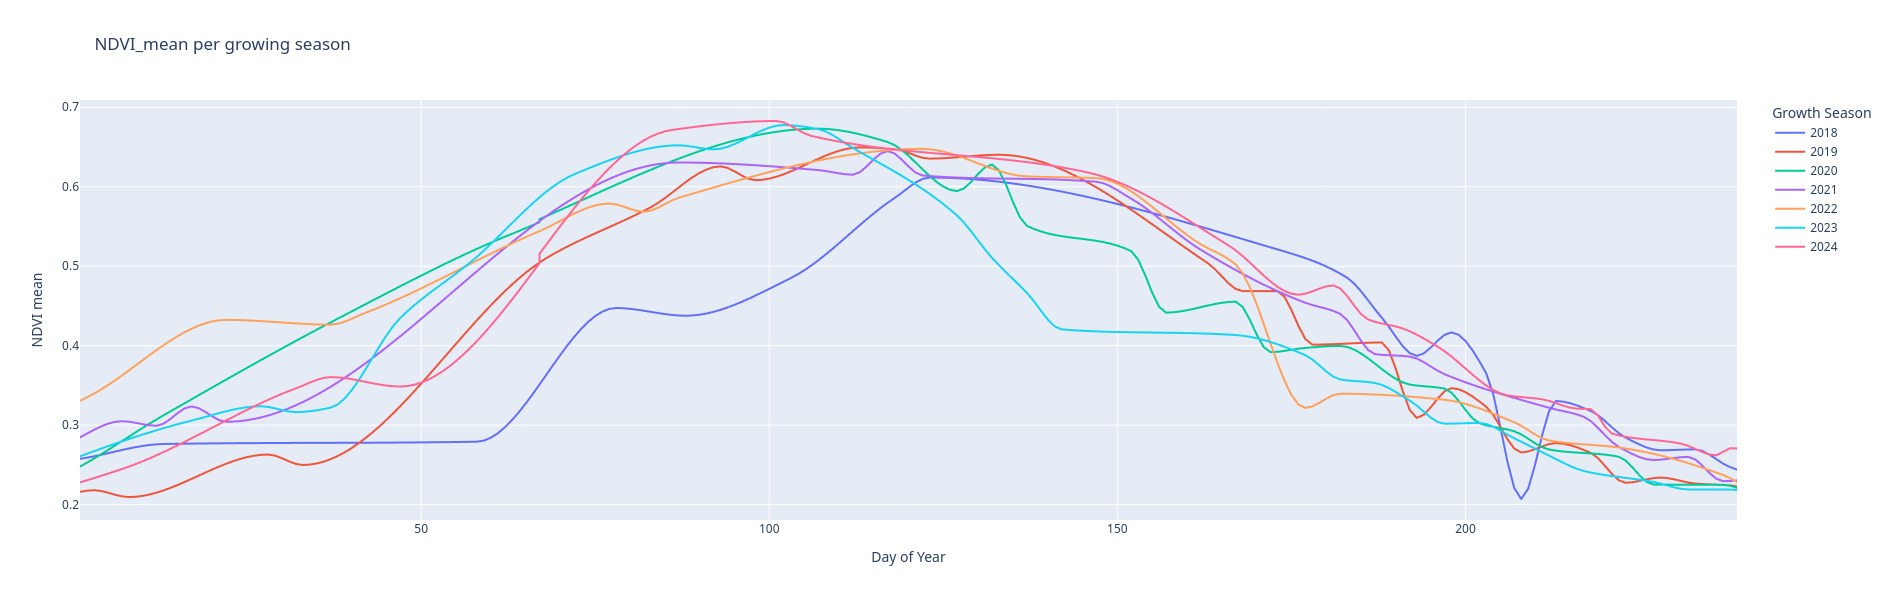

In [380]:

fig = px.line(
    summary_df, 
    x="shifted_doy", 
    y="NDVI_mean", 
    color="Ag_year",
    title="NDVI_mean per growing season",
    labels={"shifted_doy": "Day of Year", "NDVI_mean": "NDVI mean", "Ag_year": "Growth Season"},
    template="plotly_white",
    height=600,
    width=1000,
)
fig.update_layout(template="plotly")
fig.update_layout(hovermode="x unified")


fig.show()

### Z-scores

In [381]:
[eng_features[:-2] + spectral_features]

[['precipitation',
  'cumulative_GDD',
  'temperature_2m',
  'root_weighted_soil_moisture',
  'NDVI_mean',
  'NDWI_mean',
  'NDRE_mean']]

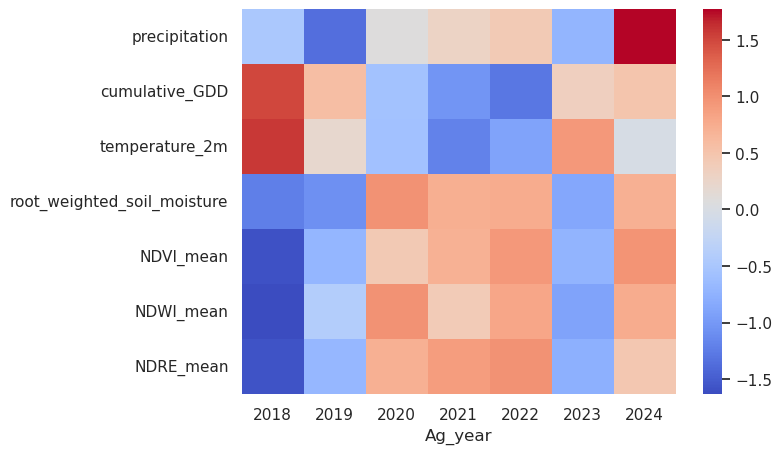

In [382]:
yearly = summary_df.groupby("Ag_year")[eng_features[:-2] + spectral_features].mean()
yearly_z = (yearly - yearly.mean()) / yearly.std()

plt.figure(figsize=(7, 5))
sns.heatmap(yearly_z.T, cmap="coolwarm")
plt.show()

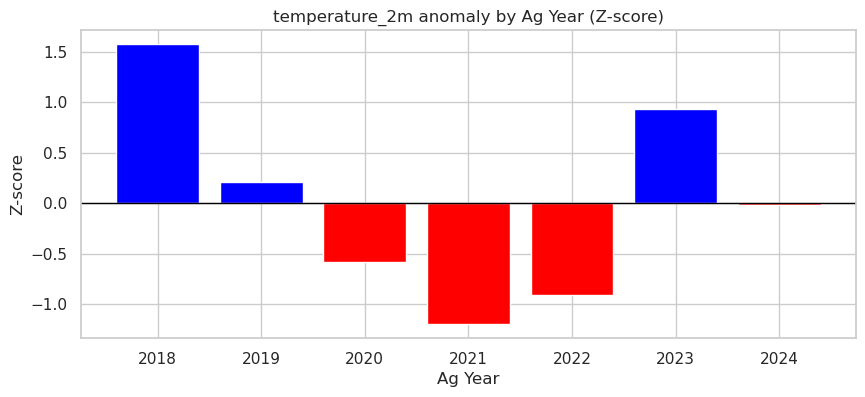

In [383]:
var = "temperature_2m"

plt.figure(figsize=(10, 4))

plt.bar(yearly_z.index, yearly_z[var], color=["red" if v < 0 else "blue" for v in yearly_z[var]])

plt.axhline(0, color="black", linewidth=1)
plt.title(f"{var} anomaly by Ag Year (Z-score)")
plt.xlabel("Ag Year")
plt.ylabel("Z-score")

plt.show()

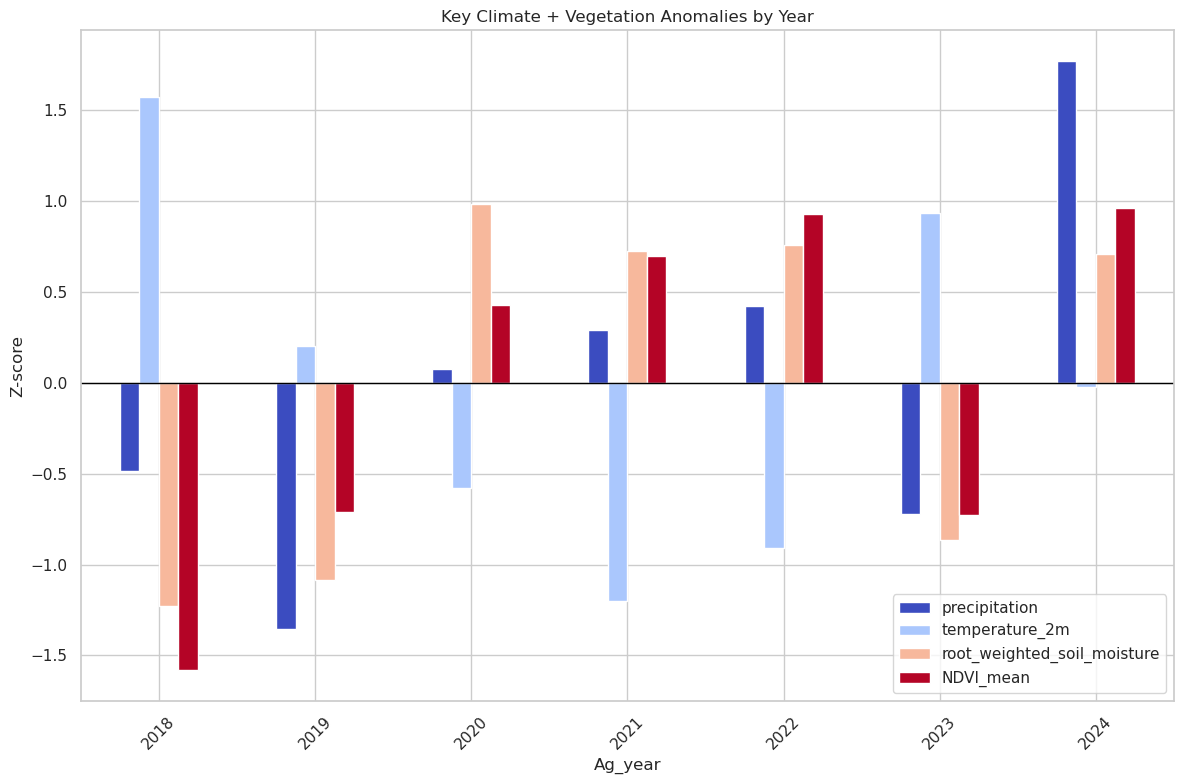

In [384]:
selected = ["precipitation", "temperature_2m", "root_weighted_soil_moisture", "NDVI_mean"]



yearly_z[selected].plot(kind="bar", figsize=(12, 8), colormap="coolwarm")
plt.axhline(0, color="black", linewidth=1)
plt.title("Key Climate + Vegetation Anomalies by Year")
plt.ylabel("Z-score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## PCA

In [385]:
eng_features = [
    'precipitation',
    'cumulative_GDD',
    'temperature_2m',
    'root_weighted_soil_moisture',
    'Shallow_mean',
    "ST_PC1",
    "VW_PC1",
    "Ag_year"
]

spectral_features = [
    'NDVI_mean',
    'NDWI_mean',
    'NDRE_mean',
]

In [386]:
interpolated_df = get_interpolated_df(
    spectral=grouped_spectral_df, 
    timestamps=eng_non_spectral_df["Timestamp"]
)

summary_df = pd.merge(interpolated_df, eng_non_spectral_df, on="Timestamp")

mask = (summary_df["in_season"] == 1) & (summary_df["Ag_year"] != 2017)
summary_df = summary_df[mask]
summary_df.head()

,Timestamp,NDVI_mean,NDWI_mean,NDRE_mean,volumetric_soil_water_layer_1,volumetric_soil_water_layer_2,volumetric_soil_water_layer_3,volumetric_soil_water_layer_4,soil_temperature_level_1,soil_temperature_level_2,...,shifted_doy,Ag_year,in_season,GDD_in_season,cumulative_GDD,Growth_Stage,root_weighted_soil_moisture,VW_PC1,Shallow_mean,ST_PC1
299,2018-10-27,0.257591,-0.072709,0.169299,0.251256,0.275675,0.275435,0.270869,297.237726,295.078666,...,1,2018,1,10.490344,10.490344,SoS,0.0,-1.506865,294.371702,1.627398
300,2018-10-28,0.259027,-0.071103,0.170494,0.248644,0.273228,0.274899,0.270852,297.756508,295.828926,...,2,2018,1,10.933870,21.424214,SoS,0.0,-1.558094,294.913417,1.835885
301,2018-10-29,0.260717,-0.069631,0.171896,0.247455,0.271179,0.274380,0.270834,298.557989,296.416195,...,3,2018,1,12.442943,33.867157,SoS,0.0,-1.591530,295.499277,2.057644
302,2018-10-30,0.262590,-0.068287,0.173448,0.245628,0.269480,0.273886,0.270816,298.301455,296.856975,...,4,2018,1,13.618227,47.485384,SoS,0.0,-1.627229,295.687618,2.143829
303,2018-10-31,0.264579,-0.067063,0.175089,0.251036,0.268644,0.273621,0.270806,293.755032,295.284433,...,5,2018,1,7.498077,54.983462,SoS,0.0,-1.584987,293.745396,1.480230


In [387]:
pca = PCA()
scaler = StandardScaler()

X = summary_df[eng_features + spectral_features].groupby("Ag_year").mean() 
X_scaled = scaler.fit_transform(X)

pca.fit(X_scaled)
explained_variance = pca.explained_variance_ratio_ * 100
cumulative_variance = np.cumsum(explained_variance)

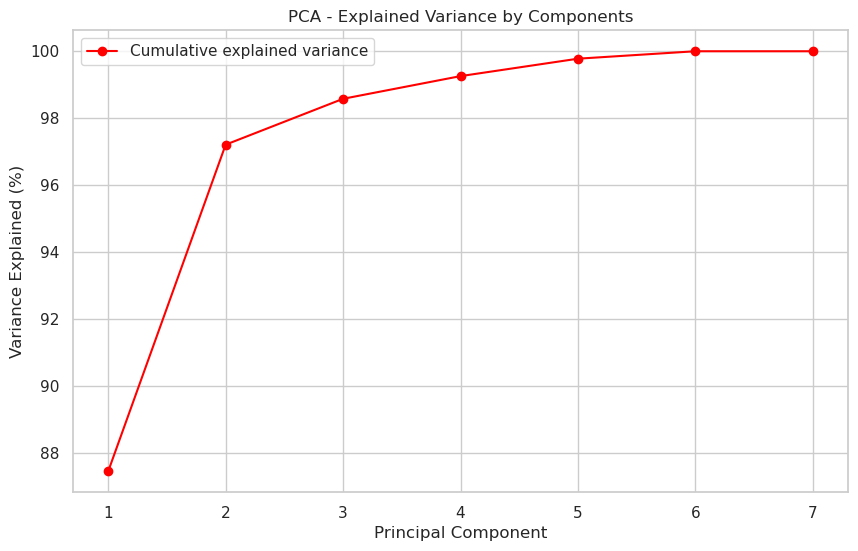

In [388]:
plt.figure(figsize=(10, 6))

components = np.arange(1, len(explained_variance) + 1)

plt.plot(components, cumulative_variance, marker='o', color='red', label='Cumulative explained variance')

plt.xlabel('Principal Component')
plt.ylabel('Variance Explained (%)')
plt.title('PCA - Explained Variance by Components')
plt.xticks(components)
plt.legend()
plt.grid(True)

plt.show()

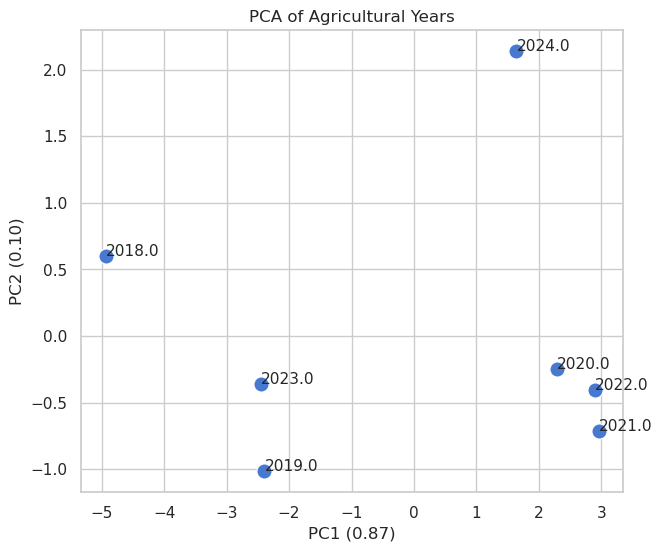

In [389]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
    index=X.index
).reset_index()

plt.figure(figsize=(7,6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", s=120)

for _, row in pca_df.iterrows():
    plt.text(row["PC1"], row["PC2"], row["Ag_year"], fontsize=11)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2f})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2f})")
plt.title("PCA of Agricultural Years")
plt.show()


In [390]:
loadings = pd.DataFrame(pca.components_.T, index=X.columns, columns=["PC1", "PC2"])

print(loadings.sort_values("PC1", ascending=False))

                                  PC1       PC2
NDRE_mean                    0.337753 -0.027020
VW_PC1                       0.332125  0.166444
NDVI_mean                    0.328639  0.174497
root_weighted_soil_moisture  0.327046  0.177389
NDWI_mean                    0.322512  0.081229
precipitation                0.221877  0.749077
cumulative_GDD              -0.298944  0.417249
temperature_2m              -0.319536  0.272961
ST_PC1                      -0.328564  0.214437
Shallow_mean                -0.328611  0.217596


In [391]:
scores = pd.DataFrame(X_pca, columns=["PC1", "PC2"], index=X.index)
print(scores)

              PC1       PC2
Ag_year                    
2018    -4.940777  0.600357
2019    -2.396118 -1.014974
2020     2.287216 -0.247890
2021     2.959403 -0.711425
2022     2.896400 -0.407372
2023    -2.448404 -0.357182
2024     1.642280  2.138486
